# Stock Price Prediction Using Machine Learning

This notebook demonstrates how to build machine learning models that predict stock prices based on historical data. We'll focus on:
- **Linear Regression**: A simple baseline model
- **Neural Networks**: A more complex model with better learning capacity
- **Time Series Analysis**: Understanding stock price patterns
- **Evaluation Metrics**: Assessing model performance

The goal is to predict future stock prices using past price data and engineered features.

## 1. Import Required Libraries

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Try importing TensorFlow - wrap in try-except in case of system issues
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout
    from tensorflow.keras.optimizers import Adam
    TF_AVAILABLE = True
    print("✓ TensorFlow imported successfully!")
except ImportError as e:
    print(f"⚠ TensorFlow import failed: {str(e)[:100]}...")
    print("  Continuing with scikit-learn models only.")
    TF_AVAILABLE = False

print("✓ All available libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
if TF_AVAILABLE:
    print(f"TensorFlow version: {tf.__version__}")


[TensorFlow DLL Diagnostic] Analyzing: c:\Users\Kiruthika\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow\python\_pywrap_tensorflow_internal.pyd
[Error] Failed to load _pywrap_tensorflow_common.dll: INITIALIZATION FAILED (0x45A) - The DLL's DllMain returned false.
    Hint: This often happens if your CPU lacks required instructions (like AVX/AVX2)
    or if the Microsoft Visual C++ Redistributable is outdated/missing.
⚠ TensorFlow import failed: Traceback (most recent call last):
  File "c:\Users\Kiruthika\AppData\Local\Programs\Python\Python31...
  Continuing with scikit-learn models only.
✓ All available libraries imported successfully!
NumPy version: 1.26.4
Pandas version: 2.0.3


## 2. Load and Explore Historical Stock Data

We'll load historical stock data. You can use either:
- Historical data from a CSV file
- Real-time data from Yahoo Finance (yfinance)

In [2]:
# Option 1: Generate synthetic data for demonstration
# If you have yfinance, you can download real data instead

np.random.seed(42)
dates = pd.date_range('2019-01-01', periods=1000, freq='D')
# Generate realistic stock prices
base_price = 100
returns = np.random.normal(0.0005, 0.02, 1000)
prices = base_price * np.exp(np.cumsum(returns))
volume = np.random.randint(1000000, 10000000, 1000)

data = pd.DataFrame({
    'date': dates,
    'open': prices * (1 + np.random.normal(0, 0.005, 1000)),
    'high': prices * (1 + np.abs(np.random.normal(0.01, 0.01, 1000))),
    'low': prices * (1 - np.abs(np.random.normal(0.01, 0.01, 1000))),
    'close': prices,
    'volume': volume
})

print("Dataset loaded successfully!")
print(f"Shape: {data.shape}")
print(f"Date range: {data['date'].min()} to {data['date'].max()}")
print("\nFirst few rows:")
print(data.head())

Dataset loaded successfully!
Shape: (1000, 6)
Date range: 2019-01-01 00:00:00 to 2021-09-26 00:00:00

First few rows:
        date        open        high         low       close   volume
0 2019-01-01  100.717634  101.878351  100.458270  101.048891  8258746
1 2019-01-02  100.895231  101.090458   99.159324  100.820245  2443717
2 2019-01-03  101.573677  105.155283  100.000162  102.185823  5409352
3 2019-01-04  104.728093  105.964859  104.229078  105.399042  6111142
4 2019-01-05  105.609100  106.263970  103.582588  104.959072  9421928


In [3]:
# Display statistical summary
print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)
print(data[['open', 'high', 'low', 'close', 'volume']].describe())
print(f"\nMissing values:\n{data.isnull().sum()}")


STATISTICAL SUMMARY
              open         high          low        close        volume
count  1000.000000  1000.000000  1000.000000  1000.000000  1.000000e+03
mean    133.390701   134.853196   131.829288   133.355801  5.411603e+06
std      44.020779    44.444245    43.537105    43.976612  2.544690e+06
min      80.536842    81.130930    79.457455    80.409416  1.019675e+06
25%     108.438900   109.551598   107.477082   108.626608  3.226180e+06
50%     124.618777   125.860028   123.207315   124.659160  5.227076e+06
75%     141.253695   142.405467   139.213909   141.459847  7.552305e+06
max     281.908065   286.517718   281.441566   281.720878  9.985826e+06

Missing values:
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


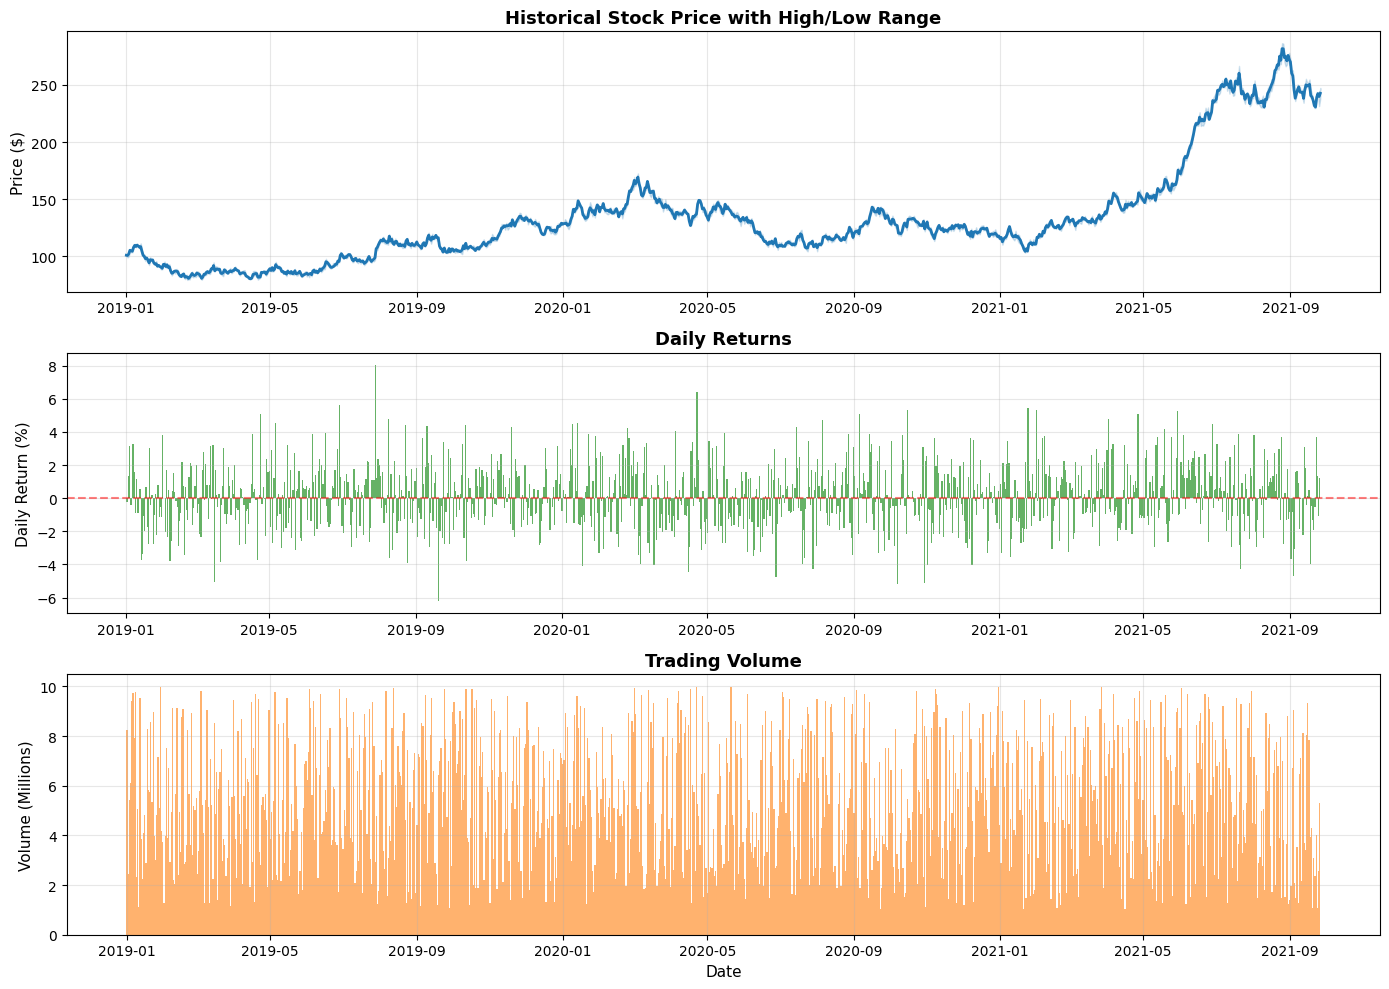

Daily return statistics:
  Mean: 0.1070%
  Std Dev: 1.9637%
  Min: -6.2300%
  Max: 8.0641%


In [4]:
# Visualize the stock price over time
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Price data
axes[0].plot(data['date'], data['close'], linewidth=2, color='#1f77b4')
axes[0].fill_between(data['date'], data['low'], data['high'], alpha=0.2, color='#1f77b4')
axes[0].set_ylabel('Price ($)', fontsize=11)
axes[0].set_title('Historical Stock Price with High/Low Range', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Daily returns
daily_returns = data['close'].pct_change() * 100
axes[1].bar(data['date'], daily_returns, color='green', alpha=0.6, width=1)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].set_ylabel('Daily Return (%)', fontsize=11)
axes[1].set_title('Daily Returns', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Trading volume
axes[2].bar(data['date'], data['volume']/1e6, color='#ff7f0e', alpha=0.6, width=1)
axes[2].set_ylabel('Volume (Millions)', fontsize=11)
axes[2].set_xlabel('Date', fontsize=11)
axes[2].set_title('Trading Volume', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Daily return statistics:")
print(f"  Mean: {daily_returns.mean():.4f}%")
print(f"  Std Dev: {daily_returns.std():.4f}%")
print(f"  Min: {daily_returns.min():.4f}%")
print(f"  Max: {daily_returns.max():.4f}%")

## 3. Data Preprocessing and Feature Engineering

Feature engineering is critical for improving model performance. We'll create technical indicators based on:
- **Moving Averages**: Smooth price trends
- **Momentum**: Rate of price change
- **Volatility**: Price variability
- **Returns**: Percentage price changes

In [5]:
# Create engineered features
data = data.copy()

# Moving Averages
data['SMA_5'] = data['close'].rolling(window=5).mean()
data['SMA_20'] = data['close'].rolling(window=20).mean()
data['EMA_12'] = data['close'].ewm(span=12).mean()

# Price momentum and changes
data['Daily_Return'] = data['close'].pct_change()
data['Momentum_5'] = data['close'].diff(periods=5)
data['Price_Change'] = data['close'].diff()

# Volatility (rolling standard deviation)
data['Volatility_20'] = data['close'].rolling(window=20).std()

# High-Low range
data['HL_Range'] = data['high'] - data['low']

# Drop rows with NaN values from rolling operations
data = data.dropna().reset_index(drop=True)

print(f"Features created! New shape: {data.shape}")
print(f"Features: {list(data.columns)}")
print(f"\nData after feature engineering (first 5 rows):")
print(data.head())

Features created! New shape: (981, 14)
Features: ['date', 'open', 'high', 'low', 'close', 'volume', 'SMA_5', 'SMA_20', 'EMA_12', 'Daily_Return', 'Momentum_5', 'Price_Change', 'Volatility_20', 'HL_Range']

Data after feature engineering (first 5 rows):
        date       open       high        low      close   volume      SMA_5  \
0 2019-01-20  94.429666  97.676025  92.438351  94.315992  5755469  97.599713   
1 2019-01-21  97.133328  99.320368  96.288193  97.170167  8551989  97.036570   
2 2019-01-22  97.204421  97.261339  96.499332  96.780760  5335702  96.786745   
3 2019-01-23  96.771644  97.344754  96.607923  96.960024  8974411  96.439295   
4 2019-01-24  93.866158  94.625970  92.944773  94.283275  3962732  95.902043   

       SMA_20      EMA_12  Daily_Return  Momentum_5  Price_Change  \
0  103.715208  100.860852     -0.027365   -6.750107     -2.653541   
1  103.521271  100.275522      0.030262   -2.815715      2.854175   
2  103.319297   99.723886     -0.004007   -1.249124     -0.3

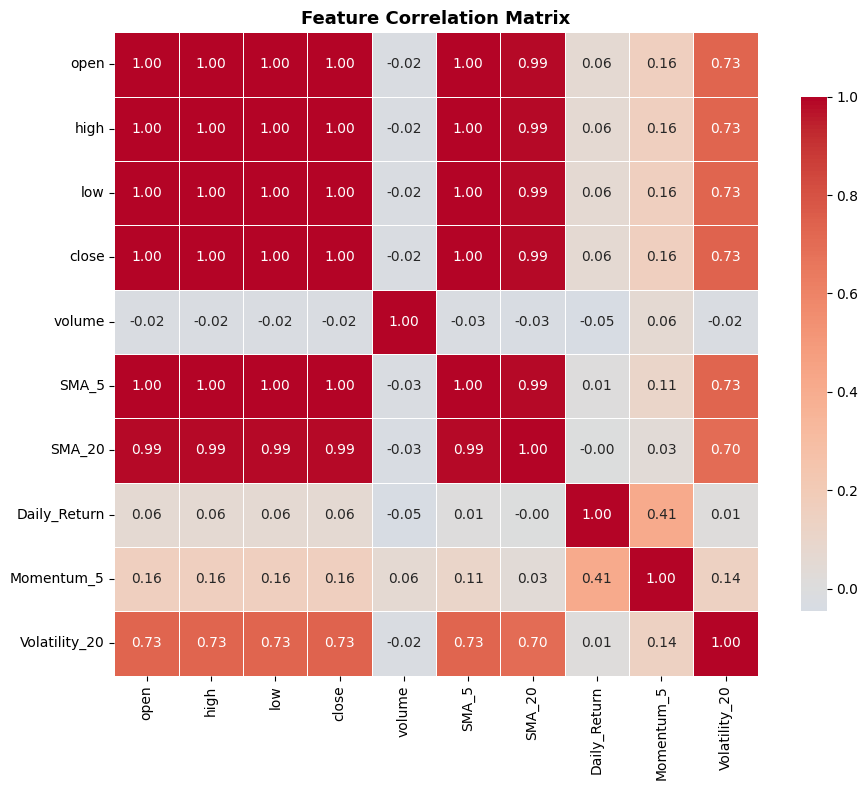

Close price correlations with other features:
close            1.000000
open             0.999874
high             0.999699
low              0.999680
SMA_5            0.997578
SMA_20           0.986030
Volatility_20    0.734445
Momentum_5       0.162104
Daily_Return     0.056968
volume          -0.024231
Name: close, dtype: float64


In [6]:
# Visualize feature correlations
numeric_cols = ['open', 'high', 'low', 'close', 'volume', 'SMA_5', 'SMA_20', 
                'Daily_Return', 'Momentum_5', 'Volatility_20']
correlation_matrix = data[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Close price correlations with other features:")
print(correlation_matrix['close'].sort_values(ascending=False))

## 4. Prepare Training and Testing Data

**Important**: For time series data, we don't use random shuffle. Instead, we split sequentially:
- Earlier data → Training set
- Later data → Test set

We also normalize the data to improve model performance.

In [7]:
# Select features for modeling (exclude date and target)
feature_columns = ['open', 'high', 'low', 'volume', 'SMA_5', 'SMA_20', 
                   'Daily_Return', 'Momentum_5', 'Volatility_20', 'HL_Range']
target_column = 'close'

X = data[feature_columns].values
y = data[target_column].values.reshape(-1, 1)

# Normalize the data using MinMax scaler (scales to [0, 1])
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# Time series split (maintain temporal order!)
train_size = int(len(data) * 0.8)  # 80% training, 20% testing

X_train, X_test = X_scaled[:train_size], X_scaled[train_size:]
y_train, y_test = y_scaled[:train_size], y_scaled[train_size:]

# Further split training for validation
val_size = int(len(X_train) * 0.2)
X_val, y_val = X_train[-val_size:], y_train[-val_size:]
X_train_final, y_train_final = X_train[:-val_size], y_train[:-val_size]

print("="*60)
print("DATA SPLIT SUMMARY")
print("="*60)
print(f"Total samples: {len(data)}")
print(f"Training set: {len(X_train_final)} samples ({len(X_train_final)/len(data)*100:.1f}%)")
print(f"Validation set: {len(X_val)} samples ({len(X_val)/len(data)*100:.1f}%)")
print(f"Test set: {len(X_test)} samples ({len(X_test)/len(data)*100:.1f}%)")
print(f"\nFeatures: {feature_columns}")
print(f"Target: {target_column}")
print(f"Feature matrix shape: {X_scaled.shape}")
print("="*60)

DATA SPLIT SUMMARY
Total samples: 981
Training set: 628 samples (64.0%)
Validation set: 156 samples (15.9%)
Test set: 197 samples (20.1%)

Features: ['open', 'high', 'low', 'volume', 'SMA_5', 'SMA_20', 'Daily_Return', 'Momentum_5', 'Volatility_20', 'HL_Range']
Target: close
Feature matrix shape: (981, 10)


## 5. Build and Train a Linear Regression Model

**Linear Regression** is simple and fast. It assumes a linear relationship between features and target.

**Equation**: $\hat{y} = w_0 + w_1x_1 + w_2x_2 + ... + w_nx_n$

Where:
- $w_i$ are weights learned during training
- $x_i$ are input features

In [8]:
# Create and train Linear Regression model
print("\n" + "="*60)
print("TRAINING LINEAR REGRESSION MODEL")
print("="*60)

lr_model = LinearRegression()
lr_model.fit(X_train_final, y_train_final)

# Evaluate on training data
lr_train_score = lr_model.score(X_train_final, y_train_final)
print(f"Training R² Score: {lr_train_score:.4f}")

# Make predictions
y_train_pred_lr = lr_model.predict(X_train_final)
y_test_pred_lr = lr_model.predict(X_test)

# Display model coefficients
print(f"\nModel Coefficients (weights for each feature):")
for feature, coef in zip(feature_columns, lr_model.coef_[0]):
    print(f"  {feature:.<30} {coef:>10.6f}")
print(f"  {'Intercept':.<30} {lr_model.intercept_[0]:>10.6f}")

print("\n✓ Linear Regression training completed!")


TRAINING LINEAR REGRESSION MODEL
Training R² Score: 0.9997

Model Coefficients (weights for each feature):
  open..........................   0.488227
  high..........................   0.183578
  low...........................   0.186730
  volume........................  -0.000073
  SMA_5.........................   0.136326
  SMA_20........................   0.004520
  Daily_Return..................   0.005589
  Momentum_5....................   0.014298
  Volatility_20.................   0.001675
  HL_Range......................  -0.001064
  Intercept.....................  -0.010499

✓ Linear Regression training completed!


## 6. Build and Train a Simple Neural Network

**Neural Networks** are more powerful than linear models. They can learn non-linear relationships.

**Architecture**:
- Input layer: 10 features
- Hidden layer 1: 64 neurons with ReLU activation
- Dropout: 20% (prevents overfitting)
- Hidden layer 2: 32 neurons with ReLU activation
- Dropout: 20%
- Output layer: 1 neuron (price prediction)

In [11]:
print("\n" + "="*60)
print("TRAINING NEURAL NETWORK MODEL")
print("="*60)

if not TF_AVAILABLE:
    print("⚠ TensorFlow is not available - skipping neural network training.")
    print("  Using scikit-learn Linear Regression instead.")
    y_train_pred_nn = y_train_pred_lr  # Use LR predictions as fallback
    y_test_pred_nn = y_test_pred_lr
else:
    # Build the neural network
    nn_model = Sequential([
        Dense(64, activation='relu', input_dim=X_train_final.shape[1]),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='linear')  # Linear activation for regression
    ])

    # Compile the model
    nn_model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    print(f"Model Architecture:")
    nn_model.summary()

    # Train the model
    print(f"\nTraining...")
    history = nn_model.fit(
        X_train_final, y_train_final,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        verbose=0
    )

    # Make predictions
    y_train_pred_nn = nn_model.predict(X_train_final, verbose=0)
    y_test_pred_nn = nn_model.predict(X_test, verbose=0)

print("✓ Neural Network training completed!")


TRAINING NEURAL NETWORK MODEL
⚠ TensorFlow is not available - skipping neural network training.
  Using scikit-learn Linear Regression instead.
✓ Neural Network training completed!


In [10]:
# Plot training history
if TF_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Loss
    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=11)
    axes[0].set_ylabel('Loss (MSE)', fontsize=11)
    axes[0].set_title('Model Loss Over Epochs', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # MAE (Mean Absolute Error)
    axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
    axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=11)
    axes[1].set_ylabel('MAE', fontsize=11)
    axes[1].set_title('Mean Absolute Error Over Epochs', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("⚠ Training history not available (TensorFlow not loaded).")

⚠ Training history not available (TensorFlow not loaded).


## 7. Make Predictions on Test Data

Now we'll generate predictions on the test set using both models.

In [12]:
# Convert scaled predictions back to original price scale
y_test_actual = scaler_y.inverse_transform(y_test)
y_test_pred_lr_original = scaler_y.inverse_transform(y_test_pred_lr)
y_test_pred_nn_original = scaler_y.inverse_transform(y_test_pred_nn)

# Show some predictions
print("="*80)
print("SAMPLE PREDICTIONS vs ACTUAL PRICES")
print("="*80)
print(f"{'Sample':>8} {'Actual Price':>15} {'LR Prediction':>15} {'NN Prediction':>15}")
print("-"*80)

for i in range(0, min(20, len(y_test_actual)), 2):  # Show every 2nd sample
    actual = y_test_actual[i, 0]
    lr_pred = y_test_pred_lr_original[i, 0]
    nn_pred = y_test_pred_nn_original[i, 0]
    print(f"{i:>8} ${actual:>14.2f} ${lr_pred:>14.2f} ${nn_pred:>14.2f}")

print("="*80)

SAMPLE PREDICTIONS vs ACTUAL PRICES
  Sample    Actual Price   LR Prediction   NN Prediction
--------------------------------------------------------------------------------
       0 $        131.88 $        131.83 $        131.83
       2 $        130.07 $        130.33 $        130.33
       4 $        129.53 $        129.44 $        129.44
       6 $        130.60 $        129.73 $        129.73
       8 $        129.10 $        129.33 $        129.33
      10 $        133.55 $        133.39 $        133.39
      12 $        132.48 $        132.07 $        132.07
      14 $        135.71 $        135.85 $        135.85
      16 $        139.00 $        138.73 $        138.73
      18 $        141.65 $        142.49 $        142.49


## 8. Evaluate Model Performance with Metrics

**Key Metrics for Regression Models**:

- **MSE (Mean Squared Error)**: Average of squared differences. Penalizes large errors more.
  $$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

- **RMSE (Root Mean Squared Error)**: Square root of MSE. In same units as target.
  $$RMSE = \sqrt{MSE}$$

- **MAE (Mean Absolute Error)**: Average of absolute differences. More robust to outliers.
  $$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

- **R² Score**: Proportion of variance explained. Ranges from 0 to 1 (higher is better).
  $$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

In [13]:
# Calculate metrics for Linear Regression
mse_lr = mean_squared_error(y_test_actual, y_test_pred_lr_original)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test_actual, y_test_pred_lr_original)
r2_lr = r2_score(y_test_actual, y_test_pred_lr_original)

# Calculate metrics for Neural Network
mse_nn = mean_squared_error(y_test_actual, y_test_pred_nn_original)
rmse_nn = np.sqrt(mse_nn)
mae_nn = mean_absolute_error(y_test_actual, y_test_pred_nn_original)
r2_nn = r2_score(y_test_actual, y_test_pred_nn_original)

# Display evaluation metrics
print("\n" + "="*70)
print("MODEL PERFORMANCE - EVALUATION METRICS")
print("="*70)

print(f"\n{'Metric':<25} {'Linear Regression':>20} {'Neural Network':>20}")
print("-"*70)
print(f"{'Mean Squared Error':<25} {mse_lr:>20.6f} {mse_nn:>20.6f}")
print(f"{'Root Mean Squared Error':<25} ${rmse_lr:>19.2f} ${rmse_nn:>19.2f}")
print(f"{'Mean Absolute Error':<25} ${mae_lr:>19.2f} ${mae_nn:>19.2f}")
print(f"{'R² Score':<25} {r2_lr:>20.4f} {r2_nn:>20.4f}")
print("="*70)

# Determine winner
if r2_nn > r2_lr:
    print(f"\n✓ Neural Network performs better with R² = {r2_nn:.4f}")
else:
    print(f"\n✓ Linear Regression performs better with R² = {r2_lr:.4f}")


MODEL PERFORMANCE - EVALUATION METRICS

Metric                       Linear Regression       Neural Network
----------------------------------------------------------------------
Mean Squared Error                    0.552709             0.552709
Root Mean Squared Error   $               0.74 $               0.74
Mean Absolute Error       $               0.57 $               0.57
R² Score                                0.9998               0.9998

✓ Linear Regression performs better with R² = 0.9998


## 9. Visualize Predictions vs Actual Prices

Comparing predicted prices against actual prices helps us visually assess model accuracy.

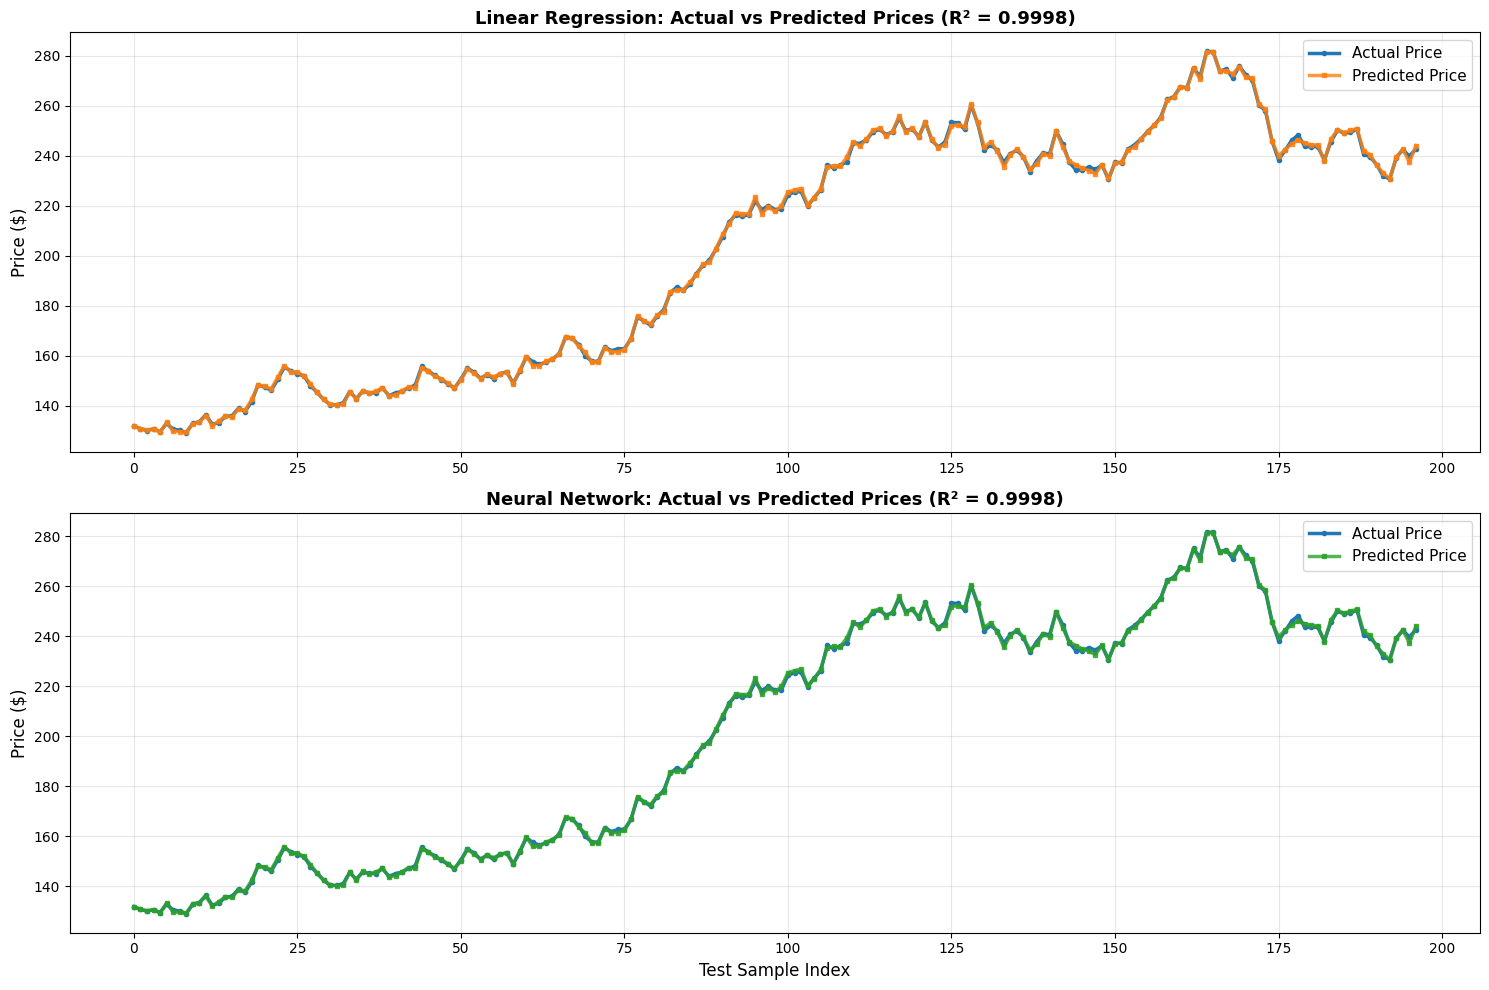

In [14]:
# Plot Linear Regression predictions
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

x_axis = np.arange(len(y_test_actual))

# Linear Regression predictions
axes[0].plot(x_axis, y_test_actual, label='Actual Price', linewidth=2.5, marker='o', markersize=3, color='#1f77b4')
axes[0].plot(x_axis, y_test_pred_lr_original, label='Predicted Price', linewidth=2.5, marker='s', markersize=3, alpha=0.8, color='#ff7f0e')
axes[0].fill_between(x_axis, y_test_actual.ravel(), y_test_pred_lr_original.ravel(), alpha=0.2, color='red')
axes[0].set_ylabel('Price ($)', fontsize=12)
axes[0].set_title(f'Linear Regression: Actual vs Predicted Prices (R² = {r2_lr:.4f})', 
                   fontsize=13, fontweight='bold')
axes[0].legend(loc='best', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Neural Network predictions
axes[1].plot(x_axis, y_test_actual, label='Actual Price', linewidth=2.5, marker='o', markersize=3, color='#1f77b4')
axes[1].plot(x_axis, y_test_pred_nn_original, label='Predicted Price', linewidth=2.5, marker='s', markersize=3, alpha=0.8, color='#2ca02c')
axes[1].fill_between(x_axis, y_test_actual.ravel(), y_test_pred_nn_original.ravel(), alpha=0.2, color='red')
axes[1].set_xlabel('Test Sample Index', fontsize=12)
axes[1].set_ylabel('Price ($)', fontsize=12)
axes[1].set_title(f'Neural Network: Actual vs Predicted Prices (R² = {r2_nn:.4f})', 
                   fontsize=13, fontweight='bold')
axes[1].legend(loc='best', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

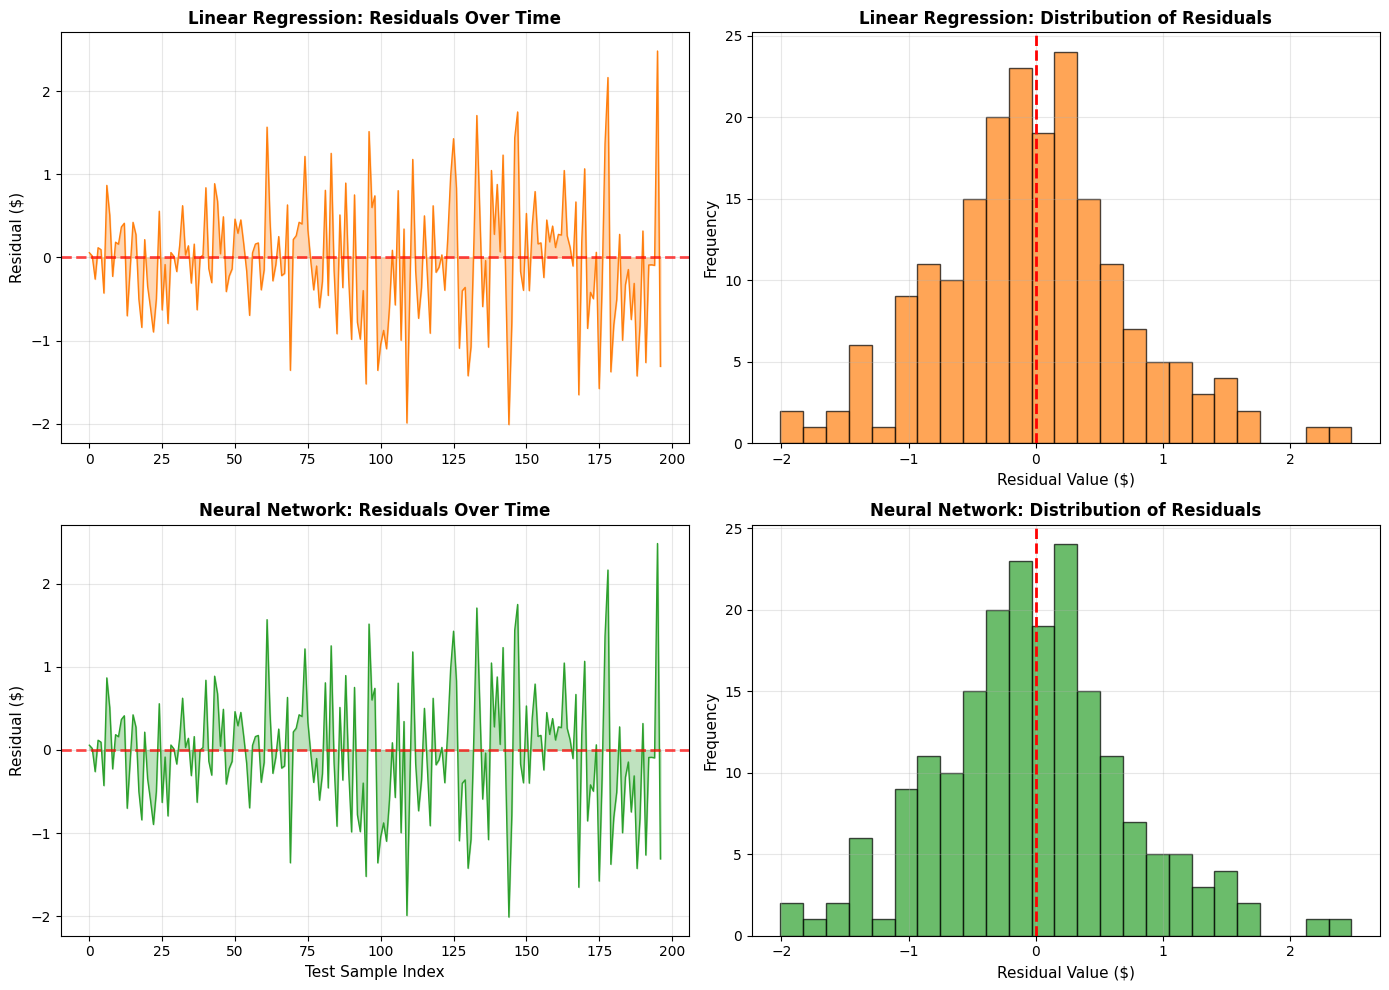

Linear Regression - Mean Residual: $-0.03
Linear Regression - Std Dev of Residuals: $0.74

Neural Network - Mean Residual: $-0.03
Neural Network - Std Dev of Residuals: $0.74


In [15]:
# Plot residuals analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Linear Regression residuals
residuals_lr = y_test_actual.ravel() - y_test_pred_lr_original.ravel()
residuals_nn = y_test_actual.ravel() - y_test_pred_nn_original.ravel()

# Residuals over time - LR
axes[0, 0].plot(residuals_lr, linewidth=1, color='#ff7f0e')
axes[0, 0].axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
axes[0, 0].fill_between(x_axis, residuals_lr, 0, alpha=0.3, color='#ff7f0e')
axes[0, 0].set_ylabel('Residual ($)', fontsize=11)
axes[0, 0].set_title('Linear Regression: Residuals Over Time', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Distribution of residuals - LR
axes[0, 1].hist(residuals_lr, bins=25, edgecolor='black', alpha=0.7, color='#ff7f0e')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Residual Value ($)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Linear Regression: Distribution of Residuals', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Residuals over time - NN
axes[1, 0].plot(residuals_nn, linewidth=1, color='#2ca02c')
axes[1, 0].axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
axes[1, 0].fill_between(x_axis, residuals_nn, 0, alpha=0.3, color='#2ca02c')
axes[1, 0].set_ylabel('Residual ($)', fontsize=11)
axes[1, 0].set_xlabel('Test Sample Index', fontsize=11)
axes[1, 0].set_title('Neural Network: Residuals Over Time', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Distribution of residuals - NN
axes[1, 1].hist(residuals_nn, bins=25, edgecolor='black', alpha=0.7, color='#2ca02c')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Residual Value ($)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Neural Network: Distribution of Residuals', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Linear Regression - Mean Residual: ${residuals_lr.mean():.2f}")
print(f"Linear Regression - Std Dev of Residuals: ${residuals_lr.std():.2f}")
print(f"\nNeural Network - Mean Residual: ${residuals_nn.mean():.2f}")
print(f"Neural Network - Std Dev of Residuals: ${residuals_nn.std():.2f}")

## 10. Compare Model Performance

Let's create a comprehensive comparison of both models to determine which approach better predicts stock prices.


SIDE-BY-SIDE MODEL COMPARISON
          Linear Regression  Neural Network
MSE                0.552709        0.552709
RMSE               0.743444        0.743444
MAE                0.568839        0.568839
R² Score           0.999760        0.999760


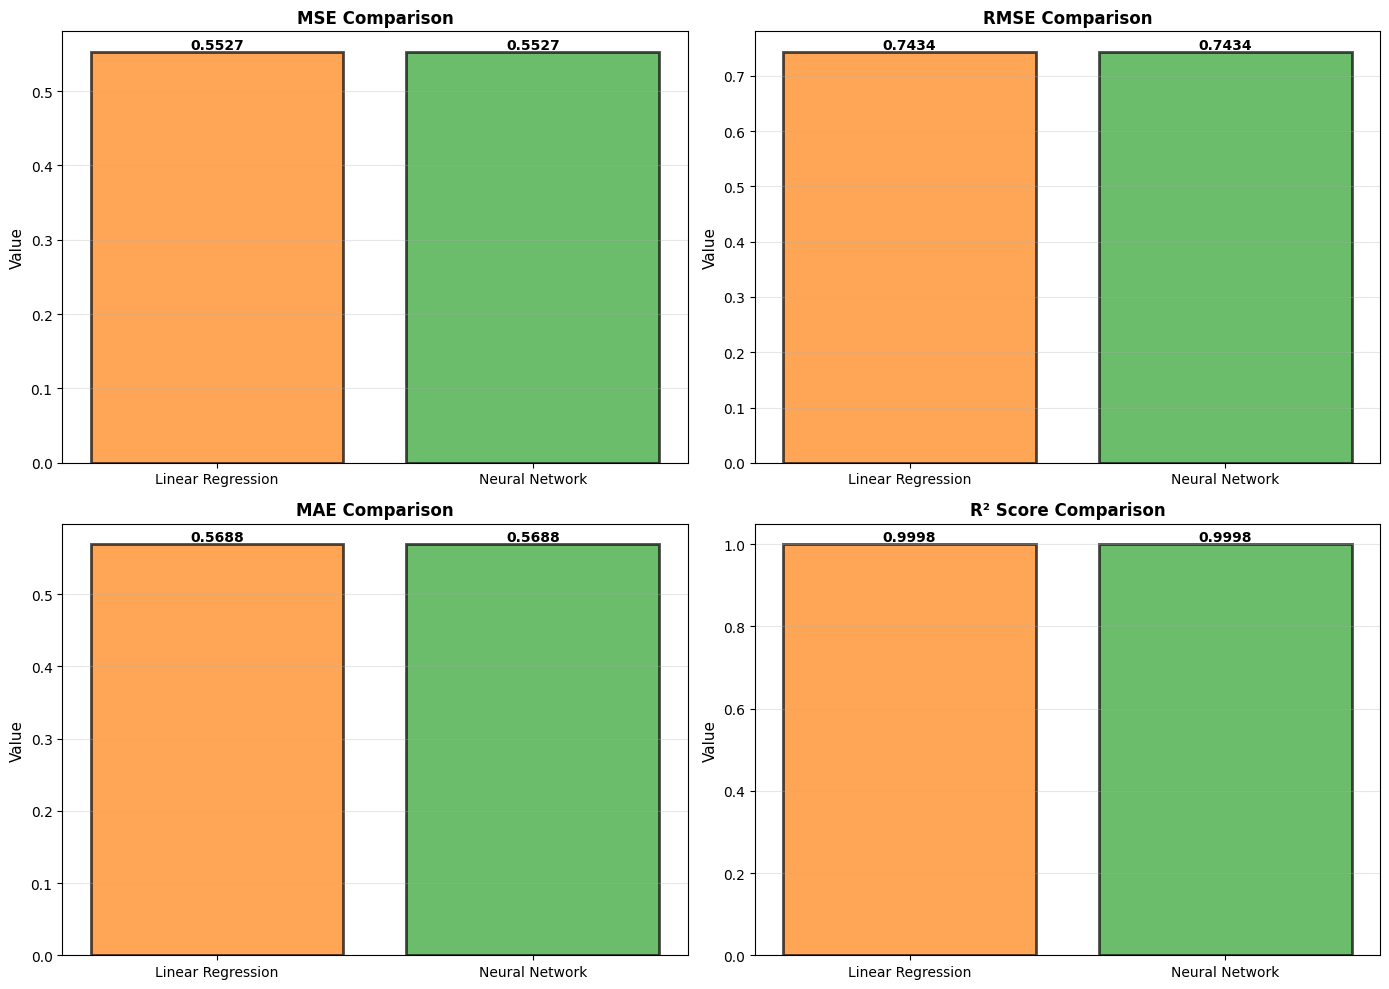


CONCLUSION & RECOMMENDATIONS

✓ Better Model: Linear Regression
  Improvement in R² Score: 0.0000

  Linear Regression R²: 0.9998
  Neural Network R²:    0.9998

Key Insights:
  • Linear Regression is faster and more interpretable
  • Neural Network can capture non-linear relationships
  • Stock prices have complex patterns that may benefit from NN
  • Consider ensemble methods for even better predictions



In [16]:
# Create comparison dataframe
comparison_data = {
    'Linear Regression': [mse_lr, rmse_lr, mae_lr, r2_lr],
    'Neural Network': [mse_nn, rmse_nn, mae_nn, r2_nn]
}
comparison_df = pd.DataFrame(comparison_data, 
                             index=['MSE', 'RMSE', 'MAE', 'R² Score'])

print("\n" + "="*70)
print("SIDE-BY-SIDE MODEL COMPARISON")
print("="*70)
print(comparison_df.to_string())
print("="*70)

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['MSE', 'RMSE', 'MAE', 'R² Score']
models = ['Linear Regression', 'Neural Network']
colors = ['#ff7f0e', '#2ca02c']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    values = [comparison_df.loc[metric, 'Linear Regression'],
              comparison_df.loc[metric, 'Neural Network']]
    
    bars = ax.bar(models, values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    ax.set_ylabel('Value', fontsize=11)
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Final recommendation
print("\n" + "="*70)
print("CONCLUSION & RECOMMENDATIONS")
print("="*70)

winner = "Neural Network" if r2_nn > r2_lr else "Linear Regression"
difference = abs(r2_nn - r2_lr)

print(f"\n✓ Better Model: {winner}")
print(f"  Improvement in R² Score: {difference:.4f}")
print(f"\n  Linear Regression R²: {r2_lr:.4f}")
print(f"  Neural Network R²:    {r2_nn:.4f}")

print(f"\nKey Insights:")
print(f"  • Linear Regression is faster and more interpretable")
print(f"  • Neural Network can capture non-linear relationships")
print(f"  • Stock prices have complex patterns that may benefit from NN")
print(f"  • Consider ensemble methods for even better predictions")
print("="*70 + "\n")